# 14. Ticket Generation Strategy

This notebook turns the final ranking model into actual lotto ticket candidates. Instead of assuming there is only one correct way to convert probabilities into six-number sets, we compare multiple generation strategies and inspect how concentrated or diversified they are.

## Bootstrap

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)

{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

## Imports

In [2]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import TABLES_DIR
from src.features import build_model_feature_bundle, load_weather_context
from src.features.temporal_features import time_based_train_test_split
from src.models.model_suite import get_probability_matrix, probability_matrix_to_number_lists
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
np.random.seed(42)

## Configuration

In [3]:
WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
RECOMMENDATION_FILE = TABLES_DIR / "table_34_final_recommendation.csv"
OVERRIDE_CANDIDATE = None  # set to dict(feature_set=..., model=..., training_regime=...) if you want to bypass notebook 12
NUM_TICKETS_PER_DRAW = 5
TOP_POOL_SIZE = 12

if not RECOMMENDATION_FILE.exists() and OVERRIDE_CANDIDATE is None:
    raise FileNotFoundError(f"Missing final recommendation table: {RECOMMENDATION_FILE}")

## Candidate and Model Helpers

In [4]:
def parse_training_regime(training_regime):
    if training_regime == "full_history":
        return None
    if isinstance(training_regime, str) and training_regime.startswith("last_"):
        return int(training_regime.split("_")[1])
    raise ValueError(f"Unsupported training regime: {training_regime}")


def apply_train_window(X_train, y_train, train_window_size):
    if train_window_size is None:
        return X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    return (
        X_train.tail(train_window_size).reset_index(drop=True),
        y_train.tail(train_window_size).reset_index(drop=True),
    )


def build_model(model_name: str, random_seed: int):
    if model_name == "logistic_regression":
        return __import__("src.models.train_baseline", fromlist=["build_logistic_regression_model"]).build_logistic_regression_model(random_seed=random_seed)
    if model_name == "random_forest":
        return __import__("src.models.train_random_forest", fromlist=["build_random_forest_model"]).build_random_forest_model(random_seed=random_seed)
    if model_name == "xgboost":
        return __import__("src.models.train_xgboost", fromlist=["build_xgboost_model"]).build_xgboost_model(random_seed=random_seed)
    if model_name == "classifier_chain":
        return __import__("src.models.train_baseline", fromlist=["build_classifier_chain_model"]).build_classifier_chain_model(random_seed=random_seed)
    if model_name == "soft_voting_ensemble":
        return __import__("src.models.train_ensemble", fromlist=["build_soft_voting_ensemble_model"]).build_soft_voting_ensemble_model(random_seed=random_seed)
    if model_name == "mlp":
        return __import__("src.models.train_mlp", fromlist=["build_scaled_mlp_model"]).build_scaled_mlp_model(random_seed=random_seed)
    raise ValueError(model_name)


def top_k_numbers(probabilities, k):
    return (np.argsort(probabilities)[::-1][:k] + 1).tolist()


def weighted_sample_without_replacement(probabilities, k, rng):
    probs = np.asarray(probabilities, dtype=float).copy()
    probs = np.clip(probs, 1e-9, None)
    probs = probs / probs.sum()
    chosen = rng.choice(np.arange(1, 46), size=k, replace=False, p=probs)
    return sorted(chosen.tolist())


def generate_greedy_ticket(probabilities):
    return sorted(top_k_numbers(probabilities, 6))


def generate_weighted_ticket(probabilities, rng):
    return weighted_sample_without_replacement(probabilities, 6, rng)


def generate_diversified_ticket(probabilities, top_pool_size=TOP_POOL_SIZE, offset=0):
    ordered = top_k_numbers(probabilities, top_pool_size)
    rotated = ordered[offset:] + ordered[:offset]
    return sorted(rotated[:6])


def overlap_size(ticket_a, ticket_b):
    return len(set(ticket_a) & set(ticket_b))

## Load Recommended Candidate and Fit Model

In [5]:
if OVERRIDE_CANDIDATE is None:
    selected = pd.read_csv(RECOMMENDATION_FILE).iloc[0].to_dict()
else:
    selected = OVERRIDE_CANDIDATE.copy()
weather_df = load_weather_context()
feature_bundle = build_model_feature_bundle(window=WINDOW, save_base=False, weather_df=weather_df)
y = feature_bundle.y.reset_index(drop=True)
LABEL_COLS = y.columns.tolist()

feature_set_name = selected["feature_set"]
model_name = selected["model"]
training_regime = selected["training_regime"]
train_window_size = parse_training_regime(training_regime)

X = feature_bundle.feature_sets[feature_set_name].reset_index(drop=True)
split = time_based_train_test_split(X, y, test_ratio=TEST_RATIO)
X_train, y_train = apply_train_window(split["X_train"], split["y_train"], train_window_size)
X_test = split["X_test"].reset_index(drop=True)
y_test = split["y_test"].reset_index(drop=True)

model = build_model(model_name, random_seed=RANDOM_SEED)
model.fit(X_train, y_train)
probability_matrix = get_probability_matrix(model, X_test)

pd.DataFrame([{
    "feature_set": feature_set_name,
    "model": model_name,
    "training_regime": training_regime,
    "n_test_rows": len(X_test),
}])

,feature_set,model,training_regime,n_test_rows
0,full_feature_set,soft_voting_ensemble,last_500,241


## Generate Ticket Strategies

In [6]:
rows = []
rng = np.random.default_rng(RANDOM_SEED)

for draw_idx, probabilities in enumerate(probability_matrix):
    greedy_ticket = generate_greedy_ticket(probabilities)
    weighted_tickets = [generate_weighted_ticket(probabilities, rng) for _ in range(NUM_TICKETS_PER_DRAW)]
    diversified_tickets = [generate_diversified_ticket(probabilities, top_pool_size=TOP_POOL_SIZE, offset=i) for i in range(NUM_TICKETS_PER_DRAW)]

    actual_numbers = sorted([int(col.split("_")[1]) for col, val in y_test.iloc[draw_idx].items() if val == 1])

    rows.append({
        "draw_index": draw_idx,
        "strategy": "greedy_top6",
        "ticket_index": 0,
        "ticket": ",".join(map(str, greedy_ticket)),
        "hit_count": len(set(greedy_ticket) & set(actual_numbers)),
        "actual_numbers": ",".join(map(str, actual_numbers)),
    })

    for ticket_idx, ticket in enumerate(weighted_tickets):
        rows.append({
            "draw_index": draw_idx,
            "strategy": "weighted_sampling",
            "ticket_index": ticket_idx,
            "ticket": ",".join(map(str, ticket)),
            "hit_count": len(set(ticket) & set(actual_numbers)),
            "actual_numbers": ",".join(map(str, actual_numbers)),
        })

    for ticket_idx, ticket in enumerate(diversified_tickets):
        rows.append({
            "draw_index": draw_idx,
            "strategy": "diversified_top_pool",
            "ticket_index": ticket_idx,
            "ticket": ",".join(map(str, ticket)),
            "hit_count": len(set(ticket) & set(actual_numbers)),
            "actual_numbers": ",".join(map(str, actual_numbers)),
        })

ticket_results = pd.DataFrame(rows)
ticket_results.head()

,draw_index,strategy,ticket_index,ticket,hit_count,actual_numbers
0,0,greedy_top6,0,"3,8,12,18,22,42",0,"5,7,13,20,21,44"
1,0,weighted_sampling,0,"3,18,31,34,39,45",0,"5,7,13,20,21,44"
2,0,weighted_sampling,1,"6,17,19,32,36,42",0,"5,7,13,20,21,44"
3,0,weighted_sampling,2,"3,8,19,23,27,37",0,"5,7,13,20,21,44"
4,0,weighted_sampling,3,"16,24,32,37,42,44",1,"5,7,13,20,21,44"


## Strategy-Level Summary

In [7]:
strategy_summary = ticket_results.groupby("strategy", as_index=False).agg(
    avg_hit=("hit_count", "mean"),
    std_hit=("hit_count", "std"),
    max_hit=("hit_count", "max"),
    ticket_count=("ticket", "size"),
)
strategy_summary = strategy_summary.sort_values(["avg_hit", "max_hit"], ascending=False).reset_index(drop=True)
strategy_summary

,strategy,avg_hit,std_hit,max_hit,ticket_count
0,greedy_top6,0.863071,0.827852,3,241
1,diversified_top_pool,0.838174,0.800459,3,1205
2,weighted_sampling,0.828216,0.810767,4,1205


## Diversity Diagnostics

In [8]:
diversity_rows = []
for strategy, frame in ticket_results.groupby("strategy"):
    frame = frame.copy()
    per_draw = frame.groupby("draw_index")["ticket"].apply(list)
    overlaps = []
    for tickets in per_draw:
        parsed = [list(map(int, ticket.split(","))) for ticket in tickets]
        for a, b in itertools.combinations(parsed, 2):
            overlaps.append(overlap_size(a, b))
    diversity_rows.append({
        "strategy": strategy,
        "mean_pairwise_overlap": float(np.mean(overlaps)) if overlaps else np.nan,
        "max_pairwise_overlap": float(np.max(overlaps)) if overlaps else np.nan,
    })

diversity_summary = pd.DataFrame(diversity_rows).sort_values("mean_pairwise_overlap")
diversity_summary

,strategy,mean_pairwise_overlap,max_pairwise_overlap
2,weighted_sampling,1.429876,5.0
0,diversified_top_pool,4.000000,5.0
1,greedy_top6,NaN,NaN


## Visual Comparison

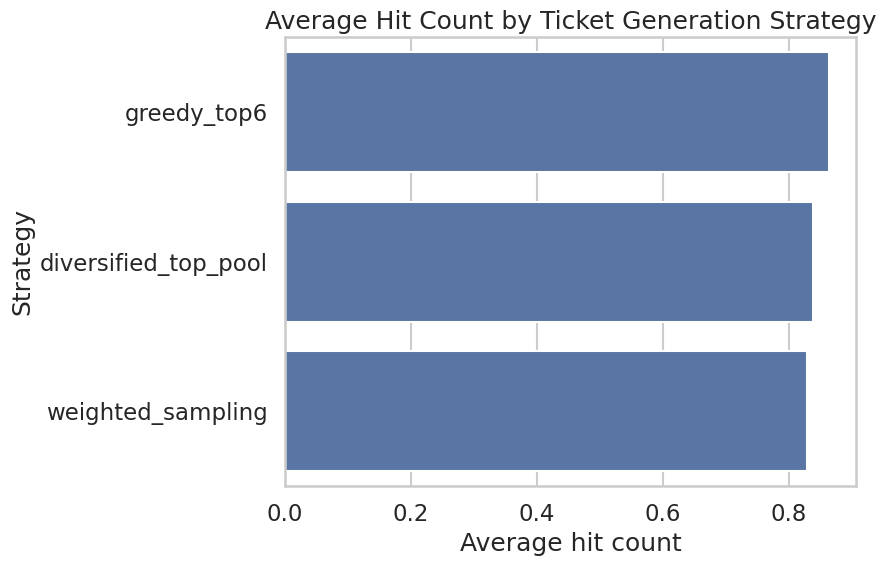

In [9]:
fig_strategy_bar, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=strategy_summary, x="avg_hit", y="strategy", ax=ax)
ax.set_title("Average Hit Count by Ticket Generation Strategy")
ax.set_xlabel("Average hit count")
ax.set_ylabel("Strategy")
plt.tight_layout()
plt.show()

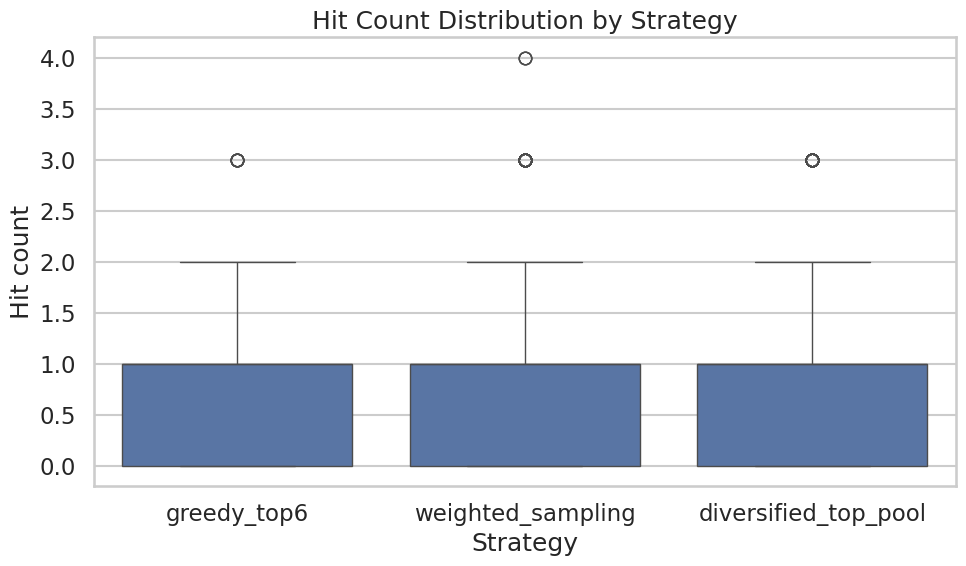

In [10]:
fig_strategy_box, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=ticket_results, x="strategy", y="hit_count", ax=ax)
ax.set_title("Hit Count Distribution by Strategy")
ax.set_xlabel("Strategy")
ax.set_ylabel("Hit count")
plt.tight_layout()
plt.show()

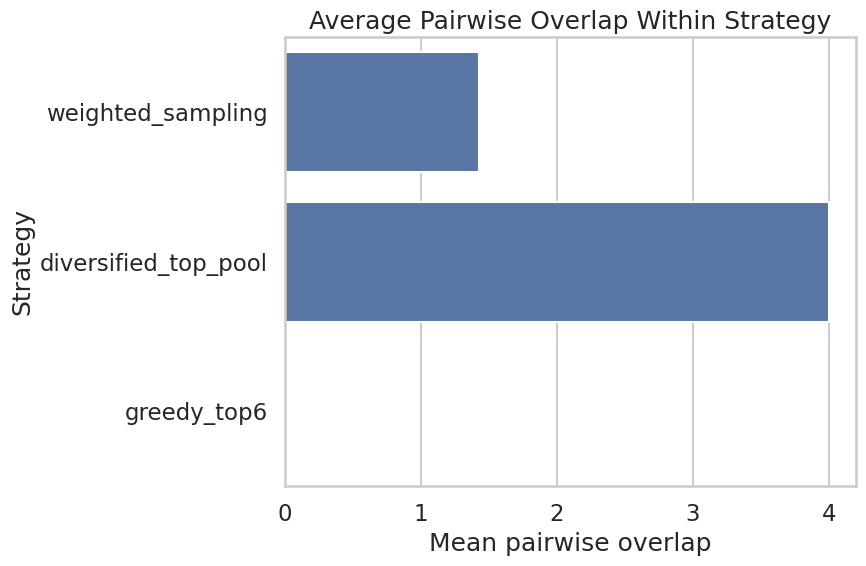

In [11]:
fig_diversity_bar, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=diversity_summary, x="mean_pairwise_overlap", y="strategy", ax=ax)
ax.set_title("Average Pairwise Overlap Within Strategy")
ax.set_xlabel("Mean pairwise overlap")
ax.set_ylabel("Strategy")
plt.tight_layout()
plt.show()

## Interpretation Notes

In [12]:
strategy_summary.merge(diversity_summary, on="strategy", how="left")

,strategy,avg_hit,std_hit,max_hit,ticket_count,mean_pairwise_overlap,max_pairwise_overlap
0,greedy_top6,0.863071,0.827852,3,241,NaN,NaN
1,diversified_top_pool,0.838174,0.800459,3,1205,4.000000,5.0
2,weighted_sampling,0.828216,0.810767,4,1205,1.429876,5.0


Read the strategy results conservatively:

- `greedy_top6` tests whether the raw ranking alone is already good enough
- `weighted_sampling` checks whether using the full probability shape gives useful variation
- `diversified_top_pool` checks whether spreading across the top probability pool creates a better portfolio of tickets
- higher average hit is useful, but overlap also matters if the goal is to avoid near-duplicate tickets

## Report Export

In [13]:
save_report_figure(fig_strategy_bar, "fig_47_ticket_strategy_avg_hit.png")
save_report_figure(fig_strategy_box, "fig_48_ticket_strategy_hit_distribution.png")
save_report_figure(fig_diversity_bar, "fig_49_ticket_strategy_diversity.png")

save_report_table(ticket_results, "table_39_ticket_strategy_full_results.csv")
save_report_table(strategy_summary, "table_40_ticket_strategy_summary.csv")
save_report_table(diversity_summary, "table_41_ticket_strategy_diversity_summary.csv")
print("Saved ticket generation strategy report artifacts.")

Saved ticket generation strategy report artifacts.
